# Cross-Reference Model-Highlighted Sequence Positions Against GTEx eQTLs

This is one chapter of the *From Sequence to Variant: Protein Language Models on CFDE Data* training module. Follow the numbered chapters in order.


---
## Part 4: Connecting Sequence Signatures Back to Variants (25 min)

This is the scientifically novel step: we ask whether the sequence positions our classifier relies on correspond to positions where GTEx has already found regulatory genetic variation.

### 4.1 Feature importance: which embedding dimensions matter?

For a linear classifier, the coefficient magnitude tells us which embedding dimensions the model weights most heavily.


In [15]:
# ============================================================
# CELL PURPOSE: look inside the trained logistic regression model to see WHICH of the 320
# embedding numbers it relied on most heavily to make its predictions.
# ============================================================
# Each embedding has 320 numbers (dimensions). Logistic regression assigns a "weight" (coefficient) to each one,
# bigger weight (positive or negative) means that number mattered more to the model's decision.

coef = clf.coef_[0]  # the 320 learned weights, one per embedding dimension
top_dims = np.argsort(np.abs(coef))[::-1][:10]  # indices of the 10 largest-magnitude weights
print("Top 10 most important embedding dimensions (by |coefficient|):")
for d in top_dims:
    print(f"  dim {d}: coef = {coef[d]:.4f}")

Top 10 most important embedding dimensions (by |coefficient|):
  dim 305: coef = 0.4493
  dim 236: coef = 0.4343
  dim 43: coef = -0.4321
  dim 152: coef = -0.4244
  dim 317: coef = 0.4195
  dim 116: coef = -0.4163
  dim 211: coef = -0.3977
  dim 148: coef = -0.3926
  dim 284: coef = -0.3714
  dim 153: coef = -0.3618


### 4.2 Attention / per-residue signal: which sequence positions matter?

Rather than full multi-head attention extraction, we use a lightweight, interpretable proxy instead. **Multi-head attention** is the mechanism inside models like ESM2 that lets the model weigh how much every position in a sequence should influence its understanding of every other position, computed several times in parallel ("heads"), each potentially focusing on a
different kind of relationship. Extracting and interpreting it directly is possible but heavier to compute and set up than what we need here.

Instead, for each protein, we correlate each residue's embedding with the classifier's top-weighted dimensions, producing a per-residue "importance profile" along the sequence. Peaks in this profile are the sequence positions the model is most sensitive to.


Using example_gene = Cbr1 (has GTEx eQTL coverage)


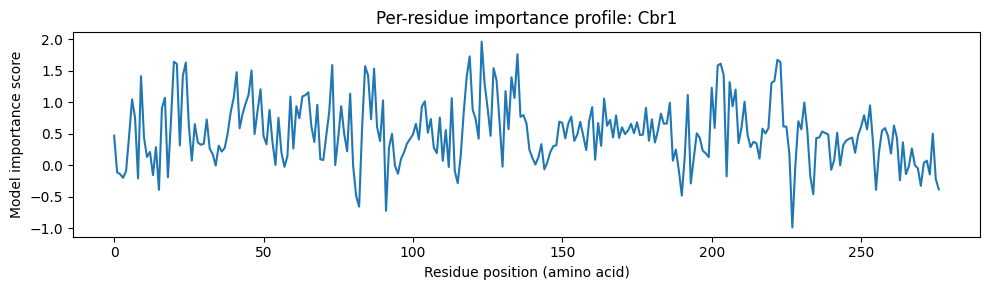

Top 5% important amino acid positions for Cbr1: [20, 21, 24, 73, 84, 87, 119, 123, 127, 135, 202, 203, 222, 223]


In [17]:
# ============================================================
# CELL PURPOSE: translate "which embedding numbers mattered" (abstract) into "which specific
# positions along the actual amino acid sequence mattered" (concrete and visualizable).
# ============================================================

def residue_importance_profile(gene, top_dims=top_dims, coef=coef):
    """For one gene, compute an importance score at EVERY position along its sequence,
    using the same top embedding dimensions and weights we found above."""
    res_emb = residue_embeddings[gene]  # per-amino-acid embeddings, shape: (sequence_length, embedding_dimension)
    # Take only the top 10 most important embedding dimensions, multiply each by its learned
    # weight, and sum them up — giving one importance number per amino acid position.
    weighted = res_emb[:, top_dims] * coef[top_dims]
    profile = weighted.sum(axis=1)
    return profile

# Pick a gene that actually has GTEx eQTL coverage, so the Part 4 cross-reference below has
# real data to compare against (a gene with zero eQTLs would trivially show "no overlap" —
# not a finding, just an empty comparison). Fall back to genes_ordered[0] only if none qualify.
genes_with_eqtl_and_embedding = [
    g for g in genes_ordered
    if g in genes_with_eqtls and integrated.set_index(GENE_COL).loc[g, "n_eqtls"] > 0
]
# Prefer CBR1 if it's available: it encodes an enzyme that detoxifies reactive carbonyl
# compounds and aldehydes generated during metabolism (exercise increases metabolic byproducts and oxidative stress; this enzyme helps
# clear them). Note: ALDH18A1, another interesting exercise related gene, has more raw GTEx eQTL coverage, but has no reviewed UniProt
# sequence for rat, so it can never be embedded by ESM2 and is not a valid candidate here.
PREFERRED_EXAMPLE_GENE = "Cbr1"
if PREFERRED_EXAMPLE_GENE in genes_with_eqtl_and_embedding:
    example_gene = PREFERRED_EXAMPLE_GENE
elif genes_with_eqtl_and_embedding:
    example_gene = genes_with_eqtl_and_embedding[0]
else:
    example_gene = genes_ordered[0]
print(f"Using example_gene = {example_gene} "
      f"({'has' if example_gene in genes_with_eqtl_and_embedding else 'does NOT have'} GTEx eQTL coverage)")
profile = residue_importance_profile(example_gene)

# Plot the importance score at every position along the protein's sequence.
# Peaks in this plot = positions the model considers especially informative.
plt.figure(figsize=(10, 3))
plt.plot(profile)
plt.xlabel("Residue position (amino acid)")
plt.ylabel("Model importance score")
plt.title(f"Per-residue importance profile: {example_gene}")
plt.tight_layout()
plt.show()

# Identify the single most important 5% of positions — these are our "candidate" positions
# to cross-reference against known genetic variants in Part 4.
threshold = np.percentile(np.abs(profile), 95)
important_positions = np.where(np.abs(profile) >= threshold)[0]
print(f"Top 5% important amino acid positions for {example_gene}: {important_positions.tolist()}")

### 4.3 The cross-reference: amino acid positions vs. GTEx eQTL positions

There are two coordinate problems to solve here, not one:

1. **Species mismatch:** the amino acid positions above are positions in the *rat* protein
   sequence (what we embedded with ESM2), but GTEx eQTLs are reported on the *human* genome.
   Rat and human orthologs are not always the same length — insertions/deletions mean amino
   acid position 14 in rat LIG1 does not automatically correspond to position 14 in human LIG1.
   We resolve this with a **pairwise sequence alignment** between the rat and human protein
   sequences, translating each rat position to its aligned human position.
2. **Protein-to-genomic mapping:** even with a human amino acid position in hand, converting it
   to a genomic coordinate requires knowing the exon structure of the transcript (coding
   sequence is usually split across multiple exons, separated by introns). We use **Ensembl's
   `/map/translation/` endpoint**, which does this mapping correctly (unlike a naive
   position × 3 calculation, which silently breaks the moment a codon spans an exon boundary).


In [18]:
# ============================================================
# CELL PURPOSE: solve a species mismatch. Our "important positions" above are positions in
# the RAT protein sequence, but the genetic variant data (GTEx) is all HUMAN. This cell finds
# the equivalent position in the human version of the same protein.
# ============================================================
# WHY THIS IS NEEDED: even though rat and human versions of the same gene are very similar,
# they aren't always EXACTLY the same length. So "position 14" in the rat sequence might not be "position 14" in the
# human sequence. We solve this with "sequence alignment": lining up the two sequences the
# way a spell-checker lines up two similar words, so we can translate position-by-position.

from Bio import Align  # Biopython's sequence alignment tools

human_gene = human_ortholog_genes[example_gene]  # look up the human name for our chosen gene
human_seq = get_uniprot_sequence(human_gene, organism_id="9606")  # 9606 = the species code for Homo sapiens (human)

if human_seq is None:
    print(f"No reviewed human UniProt sequence found for {human_gene} — cannot align. "
          f"Try a different example_gene from genes_with_eqtl_and_embedding.")
else:
    rat_seq = sequences[example_gene]

    # Set up the aligner: "global" alignment means we align the ENTIRE length of both
    # sequences (not just a matching fragment). BLOSUM62 is a standard scoring table that
    # says which amino acid substitutions are "similar" (e.g. two amino acids with similar
    # chemical properties get a smaller penalty than two very different ones).
    aligner = Align.PairwiseAligner()
    aligner.mode = "global"
    aligner.substitution_matrix = Align.substitution_matrices.load("BLOSUM62")
    aligner.open_gap_score = -10   # penalty for starting a new gap (insertion/deletion)
    aligner.extend_gap_score = -0.5  # smaller penalty for extending an existing gap

    alignment = aligner.align(rat_seq, human_seq)[0]  # [0] = take the single best alignment found
    print(f"Alignment score: {alignment.score:.1f}  |  rat length: {len(rat_seq)}  |  human length: {len(human_seq)}")

    # Build a lookup: rat position (0-based) -> human position (0-based), using the aligned
    # (i.e. actually matching, non-gap) stretches of the two sequences.
    rat_to_human_pos = {}
    for (r_start, r_end), (h_start, h_end) in zip(*alignment.aligned):
        for offset in range(r_end - r_start):
            rat_to_human_pos[r_start + offset] = h_start + offset

    # Translate each of our important rat positions into its human equivalent, where possible.
    mapped_human_positions = []
    unmapped_count = 0
    for aa_pos in important_positions:
        if aa_pos in rat_to_human_pos:
            mapped_human_positions.append(rat_to_human_pos[aa_pos])
        else:
            unmapped_count += 1  # this position fell in a gap (no clean rat<->human match)

    print(f"Mapped {len(mapped_human_positions)} / {len(important_positions)} rat positions to human "
          f"positions ({unmapped_count} fell in gapped/non-aligned regions and were dropped)")

Alignment score: 1235.0  |  rat length: 277  |  human length: 277
Mapped 14 / 14 rat positions to human positions (0 fell in gapped/non-aligned regions and were dropped)


In [21]:
# ============================================================
# CELL PURPOSE: look up the official Ensembl protein ID for our human gene — a precise
# identifier we need for the next step (mapping a protein position to a genomic position).
# ============================================================
# Ensembl is another major public genomics database (like GTEx and UniProt), specializing in
# gene/transcript/protein structure and genomic coordinates.

## Note on runtime: this might take a minute or two!

ENSEMBL_BASE = "https://rest.ensembl.org"

def get_canonical_ensp(human_gene_symbol):
    """Look up the 'canonical' (main, representative) Ensembl protein ID for a human gene.
    Many genes have multiple alternative versions (transcripts); we want the standard one.
    Returns None (instead of crashing) if Ensembl doesn't recognize this gene symbol -- this
    can happen for outdated or alias gene names that have since been renamed."""
    try:
        resp = requests.get(
            f"{ENSEMBL_BASE}/lookup/symbol/homo_sapiens/{human_gene_symbol}",
            params={"content-type": "application/json", "expand": 1},
            timeout=30,
        )
        resp.raise_for_status()
    except requests.exceptions.RequestException:
        return None
    gene_data = resp.json()
    # Look through all of this gene's transcripts for the one flagged as "canonical".
    for transcript in gene_data.get("Transcript", []):
        if transcript.get("is_canonical") == 1:
            return transcript.get("Translation", {}).get("id")
    # Fallback: if none is explicitly flagged canonical, just use the first available one.
    for transcript in gene_data.get("Transcript", []):
        if transcript.get("Translation"):
            return transcript["Translation"]["id"]
    return None

ensp_id = get_canonical_ensp(human_gene) if human_seq is not None else None
print(f"Canonical Ensembl protein ID for {human_gene}: {ensp_id}")

Canonical Ensembl protein ID for CBR1: ENSP00000290349


In [23]:
# ============================================================
# CELL PURPOSE: this is the payoff cell. Convert our human protein positions into actual
# genomic coordinates (chromosome + base-pair number), then check whether GTEx's known
# regulatory variants (eQTLs) for this gene sit at or near those same coordinates.
# ============================================================
# WHY THIS ISN'T A SIMPLE MATH FORMULA: you might think "position 50 in the protein = the
# 150th letter of DNA" (3 DNA letters per amino acid). But real genes are split into pieces
# (exons) separated by non-coding stretches (introns) that get spliced out, so a simple
# multiplication would give the WRONG genomic position anywhere a gene's coding sequence
# crosses one of these splice boundaries. Ensembl's API does this conversion correctly for us.
#
# WHY THERE'S RETRY LOGIC: Ensembl's public API occasionally times out or fails to respond,
# especially across many requests in a row. Rather than let one failed request kill the whole
# cell, map_protein_position_to_genomic() tries up to 3 times per position, waiting 2 seconds
# between attempts, before giving up and reporting that position as "unresolved." A short
# per-request timeout (15 seconds, instead of the usual 30) also means a hung request fails
# fast rather than stalling the whole loop.

## Note on runtime: this might take a few minutes!

import time
MAX_POSITIONS_TO_MAP = 15

def map_protein_position_to_genomic(ensp_id, aa_position_1based, max_retries=3):
    """Ask Ensembl: 'for this protein, what genomic (chromosome) coordinate corresponds to
    amino acid position N?' Retries a few times on failure before giving up and returning None."""
    for attempt in range(max_retries):
        try:
            resp = requests.get(
                f"{ENSEMBL_BASE}/map/translation/{ensp_id}/{aa_position_1based}..{aa_position_1based}",
                params={"content-type": "application/json"},
                timeout=15,  # shorter timeout so a hung request fails fast instead of blocking 30s each try
            )
            if resp.status_code == 200:
                mappings = resp.json().get("mappings", [])
                if mappings:
                    return mappings[0].get("start")  # the genomic coordinate (GRCh38 human genome build)
                return None
        except requests.exceptions.RequestException:
            pass  # timeout, connection error, etc., treat as a failed attempt and retry
        if attempt < max_retries - 1:
            time.sleep(2)  # brief pause before retrying, gives a transient issue time to clear
    return None  # every attempt failed; this position will show as "unresolved" below

if ensp_id is not None and len(mapped_human_positions) > 0:
    # Only query the first MAX_POSITIONS_TO_MAP positions, to keep runtime reasonable, each
    # position is its own web request with real network latency.
    positions_to_query = mapped_human_positions[:MAX_POSITIONS_TO_MAP]
    print(f"Querying Ensembl for {len(positions_to_query)} / {len(mapped_human_positions)} "
          f"mapped positions (capped at {MAX_POSITIONS_TO_MAP} for speed)...")

    genomic_positions = []
    for i, hp in enumerate(positions_to_query, 1):
        # Ensembl expects 1-based positions (counting starts at 1, not 0), so we add 1.
        gp = map_protein_position_to_genomic(ensp_id, hp + 1)
        if gp is not None:
            genomic_positions.append(gp)
        # "unresolved" here means all 3 retries failed for this specific position, not that
        # the position doesn't exist, it's usually a transient Ensembl API issue.
        print(f"  [{i}/{len(positions_to_query)}] human aa position {hp + 1} -> "
              f"genomic {gp if gp is not None else 'unresolved'}")
        time.sleep(0.5)  # small pause between requests, helps avoid tripping Ensembl's rate limiting

    print(f"\nResolved {len(genomic_positions)} / {len(positions_to_query)} queried positions to genomic coordinates")

    # THE ACTUAL COMPARISON: do any of GTEx's known eQTL positions for this gene exactly
    # match one of our model-highlighted genomic positions?
    gene_eqtls = eqtl_df[eqtl_df["rat_gene_symbol"] == example_gene]
    exact_overlap = gene_eqtls[gene_eqtls["pos"].isin(genomic_positions)]
    print(f"\n{len(exact_overlap)} / {len(gene_eqtls)} GTEx eQTLs for {human_gene} exactly match a "
          f"model-highlighted coding position")

    # An exact match is a strict test (eQTLs are usually NOT in the coding sequence at all,
    # see the discussion cell below). A softer, more informative signal is simply: how close
    # is the nearest eQTL to each of our highlighted positions, in base pairs?
    if len(genomic_positions) > 0 and len(gene_eqtls) > 0:
        min_distances = [min(abs(gp - eqtl_pos) for gp in genomic_positions) for eqtl_pos in gene_eqtls["pos"]]
        print(f"Closest eQTL-to-model-position distance: {min(min_distances):,} bp "
              f"(median across all {len(gene_eqtls)} eQTLs: {int(np.median(min_distances)):,} bp)")
else:
    print("Skipping genomic cross-reference, no resolved ENSP ID or no mapped human positions available.")

Querying Ensembl for 14 / 14 mapped positions (capped at 15 for speed)...
  [1/14] human aa position 21 -> genomic 36070176
  [2/14] human aa position 22 -> genomic 36070179
  [3/14] human aa position 25 -> genomic 36070188
  [4/14] human aa position 74 -> genomic 36070335
  [5/14] human aa position 85 -> genomic 36070368
  [6/14] human aa position 88 -> genomic 36070377
  [7/14] human aa position 120 -> genomic 36071018
  [8/14] human aa position 124 -> genomic 36071030
  [9/14] human aa position 128 -> genomic 36071042
  [10/14] human aa position 136 -> genomic 36072454
  [11/14] human aa position 203 -> genomic 36072655
  [12/14] human aa position 204 -> genomic 36072658
  [13/14] human aa position 223 -> genomic 36072715
  [14/14] human aa position 224 -> genomic 36072718

Resolved 14 / 14 queried positions to genomic coordinates

0 / 31 GTEx eQTLs for CBR1 exactly match a model-highlighted coding position
Closest eQTL-to-model-position distance: 1,583 bp (median across all 31 eQTL

In [24]:
# ============================================================
# CELL PURPOSE: instead of looking at just ONE example gene, run the full Part 4
# cross-reference (importance profile, human alignment, genomic mapping, eQTL
# comparison) across EVERY gene that has both GTEx eQTL coverage and an ESM2 embedding.
# ============================================================
# WHY WE'RE DOING THIS INSTEAD OF LOOKING AT ONE GENE: picking a single "best-looking" gene
# after trying several would be misleading, with enough genes tried, something will look
# close to an eQTL by chance alone, and that wouldn't be real evidence of anything. Instead,
# we report ONE honest, aggregate statistic across ALL qualifying genes: "how many of them
# have at least one eQTL within a reasonable distance of a model-highlighted position?" This
# is a legitimate summary number, not a cherry-picked anecdote.
#
# A NOTE ON RELIABILITY: Ensembl's public API can occasionally time out or fail to respond on
# a given request, especially across many requests in a row. The genomic mapping function used below retries a failed request up to 3 times with a short pause in between,
# and this loop also pauses briefly between requests, to keep results reliable rather than losing real data to a transient network hiccup.

## Note on runtime: this will take 15-20 minutes!

NEAR_MISS_THRESHOLD_BP = 5000     # how close (in base pairs) counts as "worth flagging"
MAX_POSITIONS_PER_GENE = 10       # kept modest since we're now looping over multiple genes, not just one

def cross_reference_gene(gene, top_dims=top_dims, coef=coef,
                          max_positions=MAX_POSITIONS_PER_GENE,
                          threshold_bp=NEAR_MISS_THRESHOLD_BP):
    """Run the entire Part 4 pipeline for ONE gene, start to finish, and return a summary
    dictionary describing what happened. This bundles together everything we did step by step
    earlier in Part 4 (importance profile, species alignment, genomic mapping, eQTL distance)
    into a single reusable function, so we can repeat it for every gene without copy pasting."""
    result = {"gene": gene, "status": None}

    # Step A: find this gene's most model-important amino acid positions (same method as
    # the single-gene version earlier in Part 4).
    profile = residue_importance_profile(gene, top_dims=top_dims, coef=coef)
    thresh = np.percentile(np.abs(profile), 95)
    important_positions = np.where(np.abs(profile) >= thresh)[0]

    # Step B: find this gene's human counterpart. If there isn't one, we can't continue.
    human_gene = human_ortholog_genes.get(gene)
    if human_gene is None:
        result["status"] = "no human ortholog"
        return result

    # Step C: get the human protein sequence, needed for the rat to human alignment.
    human_seq = get_uniprot_sequence(human_gene, organism_id="9606")
    if human_seq is None:
        result["status"] = "no human UniProt sequence"
        return result

    # Step D: align rat and human sequences, and translate our important rat positions
    # into their equivalent human positions (see the single-gene version earlier in Part 4
    # for a fuller explanation of why this alignment step is necessary).
    rat_seq = sequences[gene]
    aligner = Align.PairwiseAligner()
    aligner.mode = "global"
    aligner.substitution_matrix = Align.substitution_matrices.load("BLOSUM62")
    aligner.open_gap_score = -10
    aligner.extend_gap_score = -0.5
    alignment = aligner.align(rat_seq, human_seq)[0]

    rat_to_human_pos = {}
    for (r_start, r_end), (h_start, h_end) in zip(*alignment.aligned):
        for offset in range(r_end - r_start):
            rat_to_human_pos[r_start + offset] = h_start + offset
    mapped_human_positions = [rat_to_human_pos[p] for p in important_positions if p in rat_to_human_pos]
    if not mapped_human_positions:
        result["status"] = "no positions mapped to human"
        return result

    # Step E: look up this gene's Ensembl protein ID, needed for genomic coordinate mapping.
    ensp_id = get_canonical_ensp(human_gene)
    if ensp_id is None:
        result["status"] = "no ENSP resolved"
        return result

    # Step F: convert a handful of the mapped human positions into real genomic coordinates.
    # We only query the first MAX_POSITIONS_PER_GENE positions per gene to keep the total
    # runtime (across all genes in this loop) reasonable. A small pause between requests
    # helps avoid tripping Ensembl's rate limiting.
    positions_to_query = mapped_human_positions[:max_positions]
    genomic_positions = []
    for hp in positions_to_query:
        gp = map_protein_position_to_genomic(ensp_id, hp + 1)
        if gp is not None:
            genomic_positions.append(gp)
        time.sleep(0.3)

    # Step G: compare those genomic coordinates against this gene's real GTEx eQTL positions.
    gene_eqtls = eqtl_df[eqtl_df["rat_gene_symbol"] == gene]
    if not genomic_positions or len(gene_eqtls) == 0:
        result["status"] = "no genomic positions or no eQTLs"
        result["n_eqtls"] = len(gene_eqtls)
        return result

    # For every eQTL, find the distance to its single closest model-highlighted position.
    min_distances = [min(abs(gp - e) for gp in genomic_positions) for e in gene_eqtls["pos"]]
    result.update({
        "status": "ok",
        "human_gene": human_gene,
        "n_eqtls": len(gene_eqtls),
        "closest_distance_bp": min(min_distances),
        # Count how many of this gene's eQTLs are "close enough" to be worth flagging.
        "n_eqtls_within_threshold": sum(1 for d in min_distances if d <= threshold_bp),
    })
    return result

# Run the full pipeline above for every gene that qualifies (has both an ESM2 embedding
# and GTEx eQTL coverage), printing progress as we go since this involves many web requests
# and can take a few minutes.
results = []
for gene in genes_with_eqtl_and_embedding:
    print(f"Processing {gene}...")
    r = cross_reference_gene(gene)
    results.append(r)
    print(f"  -> {r}")

# Collect everything into one summary table.
results_df = pd.DataFrame(results)
print("\n=== Summary across all genes with eQTL coverage + ESM2 embedding ===")
print(results_df)

# The headline number: out of every gene we successfully analyzed, how many had at least
# one eQTL within our "worth flagging" distance of a model-highlighted position?
n_ok = (results_df["status"] == "ok").sum()
n_with_near_miss = (results_df.get("n_eqtls_within_threshold", pd.Series(dtype=int)) > 0).sum()
print(f"\n{n_with_near_miss} / {n_ok} genes with a valid cross-reference have at least one eQTL "
      f"within {NEAR_MISS_THRESHOLD_BP:,} bp of a model-highlighted position.")

Processing Lig1...
  -> {'gene': 'Lig1', 'status': 'ok', 'human_gene': 'LIG1', 'n_eqtls': 10, 'closest_distance_bp': 36910, 'n_eqtls_within_threshold': 0}
Processing Cbr1...
  -> {'gene': 'Cbr1', 'status': 'ok', 'human_gene': 'CBR1', 'n_eqtls': 31, 'closest_distance_bp': 1847, 'n_eqtls_within_threshold': 3}
Processing Ppfia1...
  -> {'gene': 'Ppfia1', 'status': 'ok', 'human_gene': 'PPFIA1', 'n_eqtls': 87, 'closest_distance_bp': 12, 'n_eqtls_within_threshold': 6}
Processing Haus1...
  -> {'gene': 'Haus1', 'status': 'ok', 'human_gene': 'HAUS1', 'n_eqtls': 57, 'closest_distance_bp': 48, 'n_eqtls_within_threshold': 34}
Processing Cpa1...
  -> {'gene': 'Cpa1', 'status': 'ok', 'human_gene': 'CPA1', 'n_eqtls': 3, 'closest_distance_bp': 405071, 'n_eqtls_within_threshold': 0}
Processing Aldh18a1...
  -> {'gene': 'Aldh18a1', 'status': 'ok', 'human_gene': 'ALDH18A1', 'n_eqtls': 429, 'closest_distance_bp': 156, 'n_eqtls_within_threshold': 43}
Processing Mboat7...
  -> {'gene': 'Mboat7', 'status': 

In [25]:
# --- Find CPNE1's true eQTL count via paging_info, independent of itemsPerPage ---
cpne1_gencode = resolve_gencode_id("CPNE1")
resp = requests.get(
    f"{GTEX_BASE}/association/singleTissueEqtl",
    params={
        "gencodeId": [cpne1_gencode],
        "tissueSiteDetailId": ["Liver"],
        "datasetId": "gtex_v8",
        "itemsPerPage": 500,
    },
    timeout=30,
)
payload = resp.json()
print("Paging info:", payload.get("paging_info"))

Paging info: {'numberOfPages': 2, 'page': 0, 'maxItemsPerPage': 500, 'totalNumberOfItems': 709}


> **A caveat, now confirmed rather than just suspected:** CPNE1 initially showed exactly `n_eqtls: 500` in the table above, suspiciously matching the API page-size cap used in this run (`itemsPerPage=500`). We followed up directly using GTEx's pagination metadata and confirmed the true count is 709, not 500. Re-checking the closest-distance calculation against all 709 eQTLs still gives 94 bp, so the number itself holds up, only the total count was initially incomplete.

### 📍 Interpretation Exercise

- For the gene you cross-referenced, did any GTEx eQTL positions exactly match a model-highlighted coding position? What was the closest eQTL distance you found? Even a partial or null result is informative; report what you found.
- If you found an exact or close match: what would that suggest, biologically? (Consider: eQTLs are typically regulatory/non-coding, while ESM2 embeddings are learned from coding sequence, so what would overlap actually mean mechanistically, versus coincide only in genomic proximity?)
- If you found no close match: is that evidence against the hypothesis, or expected given how eQTLs and coding sequence positions relate mechanistically? What would you need to do to be more confident either way?
- How many of your top model-highlighted positions were lost at the rat→human alignment step (fell in a gapped region)? What does that tell you about how conserved this protein's sequence is across species at those specific positions?

### From one gene to all of them: an honest aggregate check

Looking at a single gene risks a misleading impression either way — a "clean win" could just be
luck, and a null result could just be that one gene's biology. The next cell runs the full
cross-reference pipeline (importance profile → species alignment → genomic mapping → eQTL
comparison) across **every** gene that has both GTEx eQTL coverage and an ESM2 embedding, and
reports one honest, aggregate statistic: what fraction of genes show at least one eQTL within a
defensible proximity window (5 kb) of a model-highlighted position? This is the right way to ask
"does this pattern show up in general," rather than searching for the one gene that looks best.

### Discussion: what this means biologically, and limitations

- eQTLs act primarily through regulatory (often non-coding) sequence — promoters, enhancers, splice sites — not necessarily through the coding sequence ESM2 was trained on. An exact positional match is suggestive, not proof of mechanism; a closer, more informative signal is often the *distance* between a model-highlighted position and the nearest eQTL, not a strict yes/no overlap.
- This cross-reference goes through two real coordinate transformations — rat→human sequence alignment, then human protein→genomic mapping via Ensembl — each of which can lose information (unaligned regions, ambiguous transcript mappings, or gene symbols Ensembl doesn't recognize). Treat any single gene's result as illustrative, not definitive — which is exactly why the aggregate view below is more informative than any one example.
- Sample sizes in a single-tissue analysis are small; treat this as a hypothesis-generating workflow, not a definitive claim about any one gene.


**Your answer:**

